# Нахождение корней уравнений

In [61]:
import sys

sys.path.append('..')

### 1. Метод последовательного поиска

##### Пример:

$$x^4-6.4x^3+6.45x^2+20.538x-31.752=0$$


Нарисуем графики функции:

$$y =x^4$$

и 

$$z = 6.4x^3-6.45x^2-20.538x+31.752$$

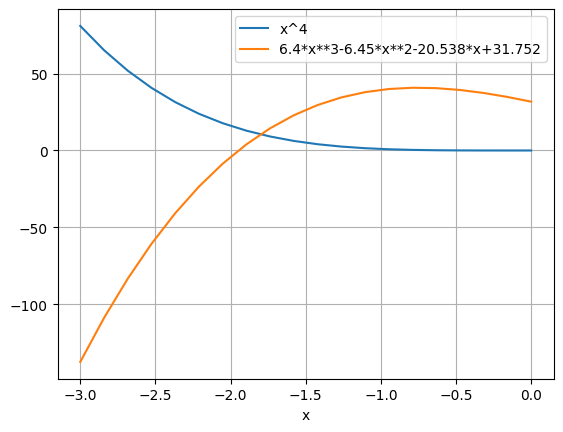

In [62]:
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(-3, 0, 20)

y = x**4
z = 6.4*x**3-6.45*x**2-20.538*x+31.752

plt.xlabel('x')
plt.grid(True)
plt.plot(x, y, label='x^4')
plt.plot(x, z, label='6.4*x**3-6.45*x**2-20.538*x+31.752')
plt.legend(loc='upper right')
plt.show()

Пусть:

$$f(x) = x^4-6.4x^3+6.45x^2+20.538x-31.752$$

In [63]:
from math import log
from modules.equations.single import root_search

def f(x: float): return x**4-6.4*x**3+6.45*x**2+20.538*x-31.752

x1, x2 = root_search(f, -3, 0, 0.001)

x1, x2

(-1.8000000000001322, -1.7990000000001323)

In [64]:
f(x1), f(x2)

(1.1663559007502045e-11, -0.08815756358733395)

### 2. Метод бисекции

In [65]:
from modules.equations.single import bisection

x = bisection(f, -3, 0, 10**-9)

x

-1.7999999999301508

In [66]:
f(x)

-6.161950949490347e-09

### 3. Метод Риддера

In [67]:
from modules.equations.single import ridder

x, iter = ridder(f, -3, 0, 10**-9, 100)

x, iter

(-1.7999999999999998, 9)

In [68]:
f(x)

-1.0658141036401503e-14

### 4. Метод Ньютона-Рафсона

$$f'(x) = \frac{1}{x} - 1$$

In [69]:
from modules.equations.single import newton_raphson

def df(x: float): return 1. / x - 1.

x, iter = newton_raphson(f, df, -3, 0, 10**-9, 100)

x, iter

(-1.7999999995809048, 31)

In [70]:
f(x)

-3.697173767136519e-08

### 5. Метод Ньютона-Рафсона для системы уравнении

##### Пример:

$$3𝑥^2y^2+x^2-3xy=7$$

$$10x^2y^2+3x^2-20xy=3$$

In [71]:
import numpy as np
from modules.equations.system import newton_raphson_system

def f(x: np.ndarray[np.double]) -> np.ndarray[np.double]:
    fx = np.zeros(len(x))

    fx[0] = 3 * x[0]**2 * x[1]**2 + x[0]**2 - 3 * x[0] * x[1] - 7
    fx[1] = 10 * x[0]**2 * x[1]**2 + 3 * x[0]**2 - 20 * x[0] * x[1] - 3

    return fx

x = np.array([1., 1.])

x, iter = newton_raphson_system(f, x, 10**-4, 10**-9, 100)

x, iter

(array([1., 2.]), 10)

In [72]:
f(x)

array([2.57571742e-13, 8.31335001e-13])